## Technology Sector Growth Trajectory

All three tech mega-caps grew substantially over 2009-2022:
- AAPL: $42.9B → $394.3B (9.2× multiple)
- GOOG: $23.7B → $282.8B (12× multiple)
- MSFT: $58.4B → $198.3B (3.4× multiple)

The parallel movement across years confirms sector-tailwind dynamics — 
these companies rose together during expansion cycles and slowed together 
during corrections. Sector-level story is real.

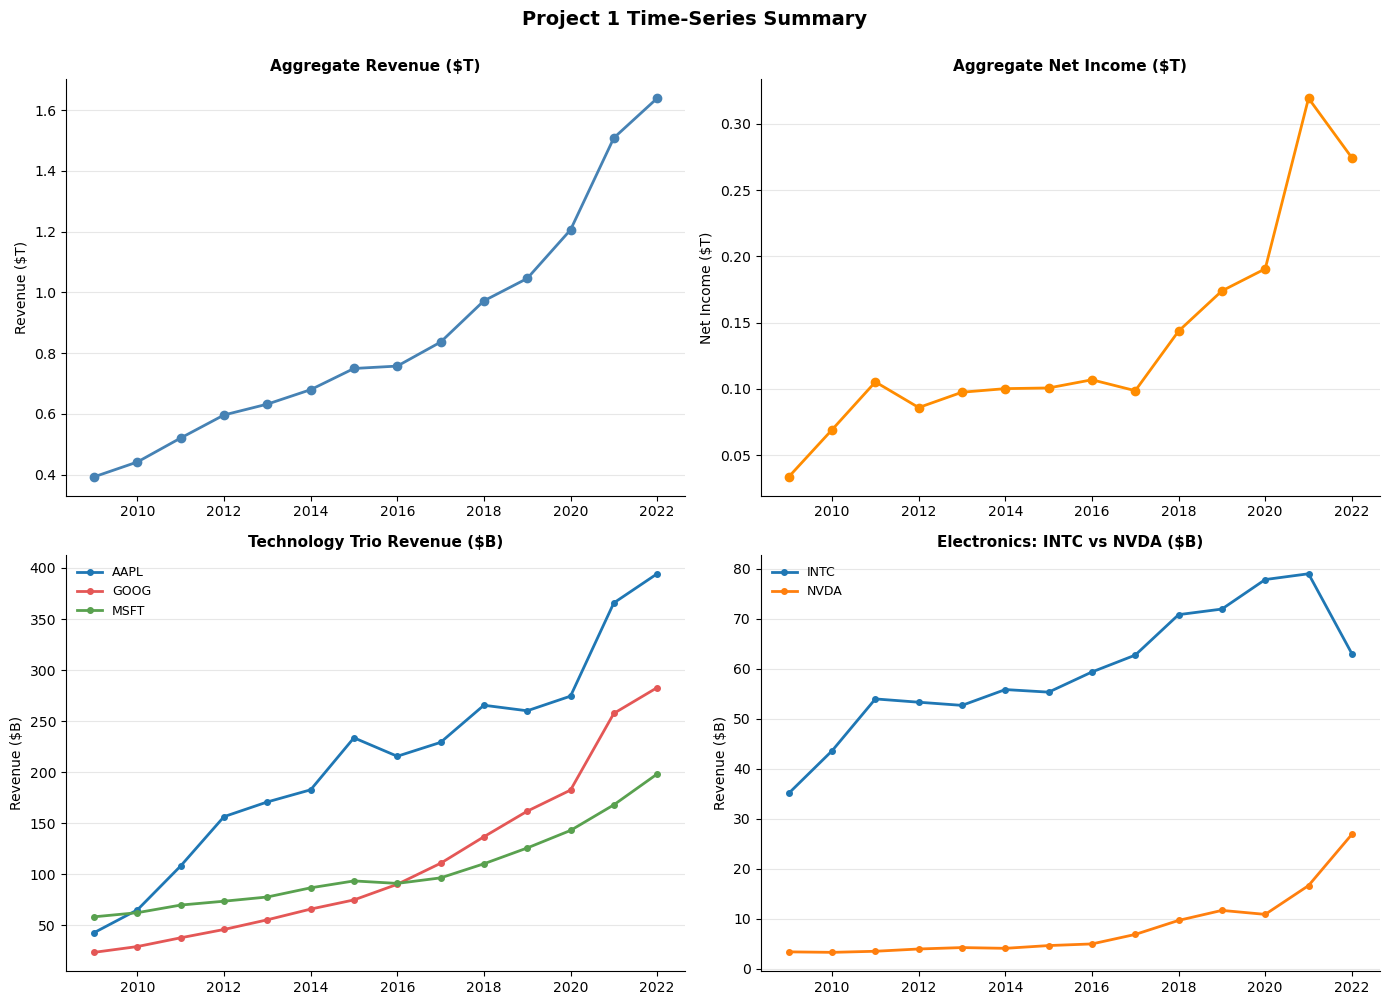

In [25]:
# 2v2 Grid of Subplots.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Aggregate Revenue
axes[0, 0].plot(yearly["Year"], yearly["revenue_trillions"], 
                color="steelblue", marker="o", linewidth=2)
axes[0, 0].set_title("Aggregate Revenue ($T)", fontsize=11, fontweight="bold")
axes[0, 0].set_ylabel("Revenue ($T)")
axes[0, 0].spines["top"].set_visible(False)
axes[0, 0].spines["right"].set_visible(False)
axes[0, 0].grid(axis="y", alpha=0.3)

# Top-right: Aggregate Net Income
axes[0, 1].plot(yearly["Year"], yearly["ni_trillions"], 
                color="darkorange", marker="o", linewidth=2)
axes[0, 1].set_title("Aggregate Net Income ($T)", fontsize=11, fontweight="bold")
axes[0, 1].set_ylabel("Net Income ($T)")
axes[0, 1].spines["top"].set_visible(False)
axes[0, 1].spines["right"].set_visible(False)
axes[0, 1].grid(axis="y", alpha=0.3)

# Bottom-left: Technology trio
for company in ["AAPL", "GOOG", "MSFT"]:
    company_data = tech_df[tech_df["Company"] == company]
    axes[1, 0].plot(company_data["Year"], company_data["revenue_billions"], 
                    marker="o", markersize=4, linewidth=2,
                    color=company_colors[company],
                    label=company)
axes[1, 0].set_title("Technology Trio Revenue ($B)", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Revenue ($B)")
axes[1, 0].legend(loc="upper left", frameon=False, fontsize=9)
axes[1, 0].spines["top"].set_visible(False)
axes[1, 0].spines["right"].set_visible(False)
axes[1, 0].grid(axis="y", alpha=0.3)

# Bottom-right: Electronics divergence
for company in ["INTC", "NVDA"]:
    company_data = electronics_df[electronics_df["Company"] == company]
    axes[1, 1].plot(company_data["Year"], company_data["Revenue"] / 1000, 
                    marker="o", markersize=4, linewidth=2,
                    label=company)
axes[1, 1].set_title("Electronics: INTC vs NVDA ($B)", fontsize=11, fontweight="bold")
axes[1, 1].set_ylabel("Revenue ($B)")
axes[1, 1].legend(loc="upper left", frameon=False, fontsize=9)
axes[1, 1].spines["top"].set_visible(False)
axes[1, 1].spines["right"].set_visible(False)
axes[1, 1].grid(axis="y", alpha=0.3)

fig.suptitle("Project 1 Time-Series Summary", fontsize=14, fontweight="bold", y=1.00)

plt.tight_layout()
# ...ending with:
plt.savefig("outputs/project1_summary_grid.png", dpi=300, bbox_inches="tight")
plt.show()

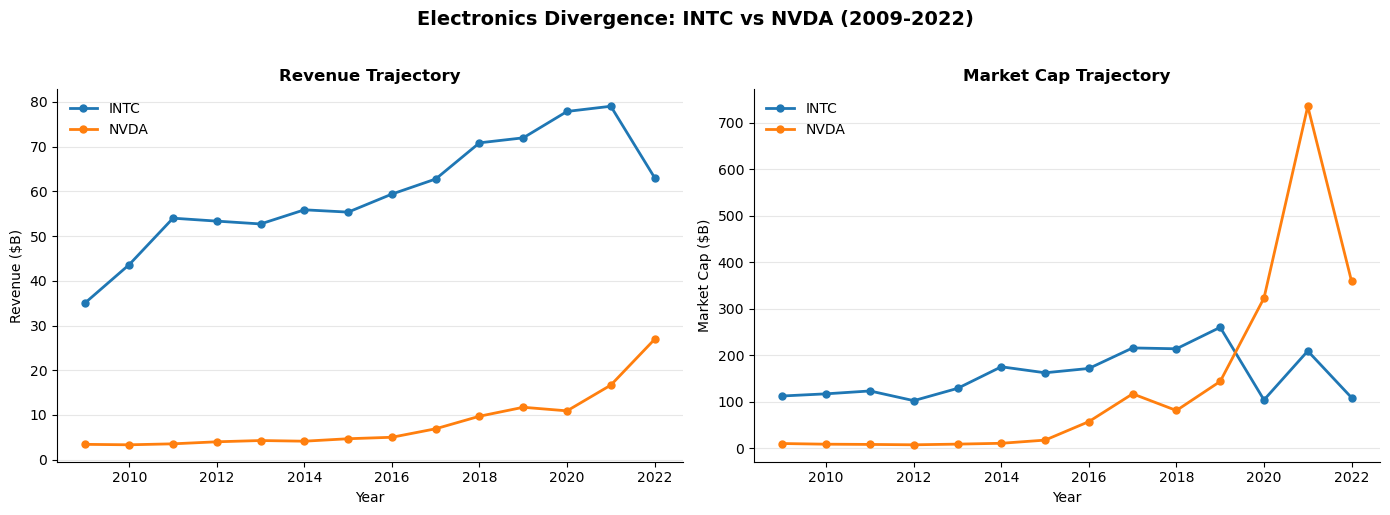

In [24]:
# Subplots - Side by Side Charts
# Subplots - multiple charts in one figure, multi panel dashboard possible due to this.

# INTC vs. NVDA in Two Panels
electronics_df = df[df["sector"] == "Electronics"].copy()
electronics_df = electronics_df.sort_values(["Company", "Year"])

# Two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT PANEL: Revenue
for i, company in enumerate(["INTC", "NVDA"]):
    company_data = electronics_df[electronics_df["Company"] == company]
    axes[0].plot(company_data["Year"], company_data["Revenue"] / 1000, 
                 marker="o", markersize=5, linewidth=2,
                 label=company)

axes[0].set_title("Revenue Trajectory", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Revenue ($B)")
axes[0].legend(loc="upper left", frameon=False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(axis="y", alpha=0.3)

# RIGHT PANEL: Market Cap
for i, company in enumerate(["INTC", "NVDA"]):
    company_data = electronics_df[electronics_df["Company"] == company]
    axes[1].plot(company_data["Year"], company_data["Market Cap(in B USD)"], 
                 marker="o", markersize=5, linewidth=2,
                 label=company)

axes[1].set_title("Market Cap Trajectory", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Market Cap ($B)")
axes[1].legend(loc="upper left", frameon=False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(axis="y", alpha=0.3)

# Overall title
fig.suptitle("Electronics Divergence: INTC vs NVDA (2009-2022)", 
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
# ...ending with:
plt.savefig("outputs/electronics_divergence.png", dpi=300, bbox_inches="tight")
plt.show()

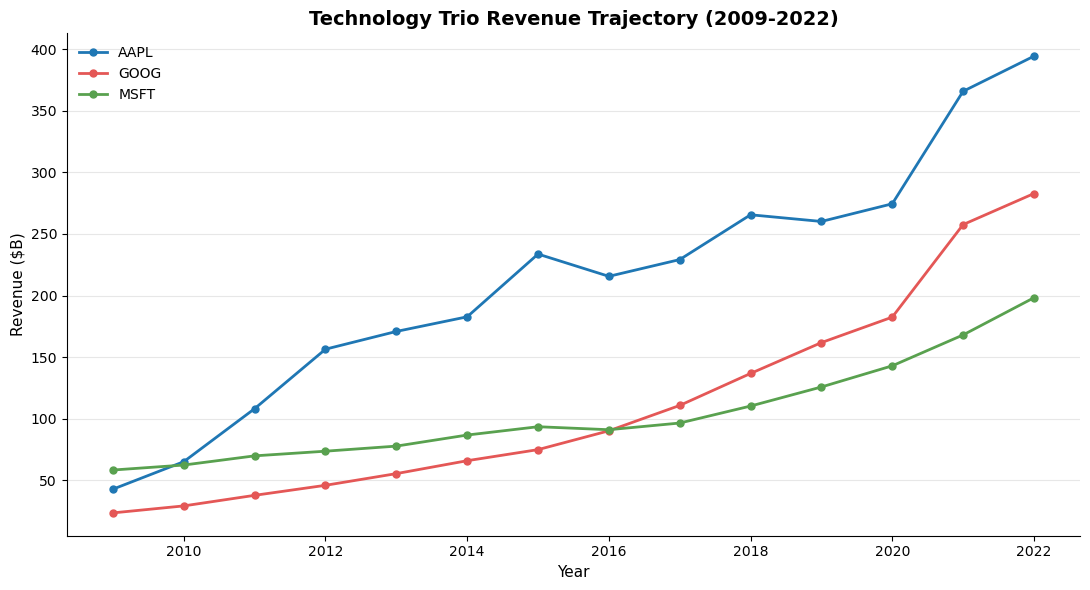

In [ ]:
# Custom Colours per Company (similar to Power BI)
company_colors = {
    "AAPL": "#1F77B4",   # Blue
    "GOOG": "#E45756",   # Red  
    "MSFT": "#59A14F",   # Green
}

fig, ax = plt.subplots(figsize=(11, 6))

for company in ["AAPL", "GOOG", "MSFT"]:
    company_data = tech_df[tech_df["Company"] == company]
    ax.plot(company_data["Year"], company_data["revenue_billions"], 
            marker="o", markersize=5, linewidth=2,
            color=company_colors[company],
            label=company)

ax.set_title("Technology Trio Revenue Trajectory (2009-2022)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Revenue ($B)", fontsize=11)
ax.legend(loc="upper left", frameon=False, fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
# ...ending with:
plt.savefig("outputs/tech_trio_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

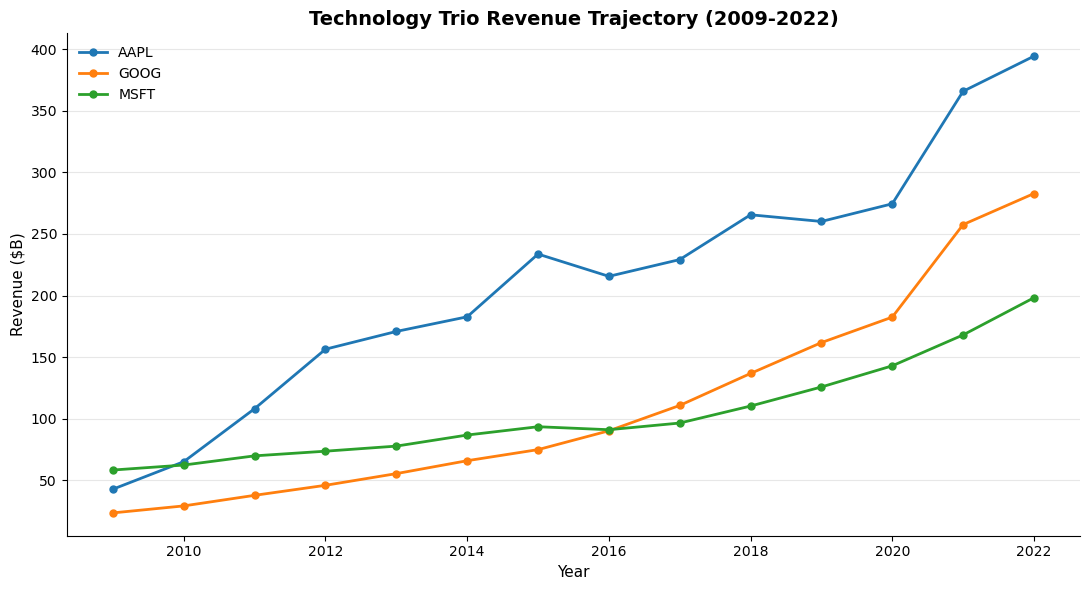

In [22]:
# Three Lines on One Chart.
fig, ax = plt.subplots(figsize=(11, 6))

# Plot each company as a separate line
for company in ["AAPL", "GOOG", "MSFT"]:
    company_data = tech_df[tech_df["Company"] == company]
    ax.plot(company_data["Year"], company_data["revenue_billions"], 
            marker="o", markersize=5, linewidth=2,
            label=company)

ax.set_title("Technology Trio Revenue Trajectory (2009-2022)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Revenue ($B)", fontsize=11)
ax.legend(loc="upper left", frameon=False, fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
# ...ending with:
plt.savefig("outputs/tech_trio_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Multi Series Line Chart - Tech Trio.
tech_df = df[df["sector"] == "Technology"].copy()
tech_df = tech_df.sort_values(["Company", "Year"])

# Convert revenue to billions
tech_df["revenue_billions"] = tech_df["Revenue"] / 1000

tech_df[["Company", "Year", "revenue_billions"]].head(10)


,Company,Year,revenue_billions
13,AAPL,2009,42.905
12,AAPL,2010,65.225
11,AAPL,2011,108.249
10,AAPL,2012,156.508
9,AAPL,2013,170.910
8,AAPL,2014,182.795
7,AAPL,2015,233.715
6,AAPL,2016,215.639
5,AAPL,2017,229.234
4,AAPL,2018,265.595


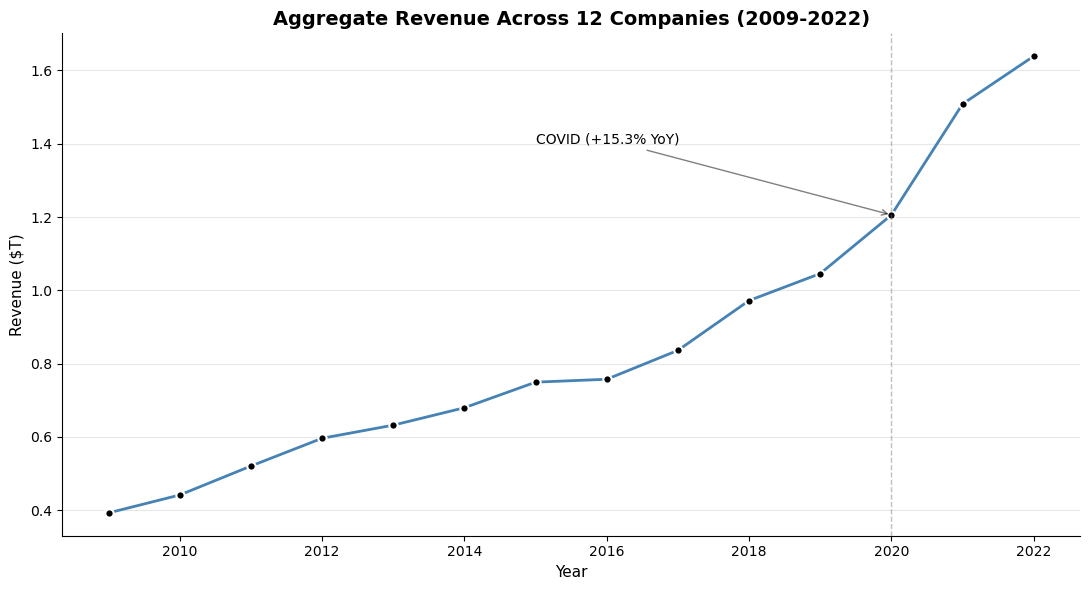

In [21]:
# Highlight a Specific Year. (e.g. Covid 2020)
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(yearly["Year"], yearly["revenue_trillions"], 
        color="steelblue", linewidth=2,
        marker="o", markersize=6,
        markerfacecolor="black", markeredgecolor="white", markeredgewidth=1.5)

# Highlight the COVID year
ax.axvline(x=2020, color="grey", linestyle="--", linewidth=1, alpha=0.5)
ax.annotate("COVID (+15.3% YoY)", 
            xy=(2020, yearly[yearly["Year"] == 2020]["revenue_trillions"].values[0]),
            xytext=(2015, 1.4),
            fontsize=10, color="black",
            arrowprops=dict(arrowstyle="->", color="black", alpha=0.5))

ax.set_title("Aggregate Revenue Across 12 Companies (2009-2022)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Revenue ($T)", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
# ...ending with:
plt.savefig("outputs/aggregate_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

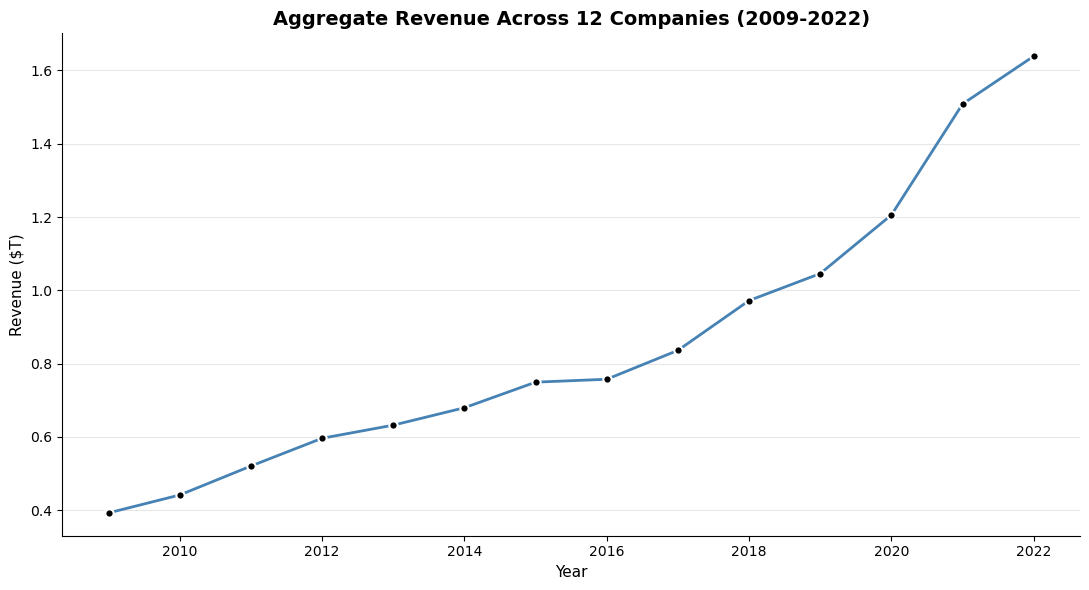

In [ ]:
# Add Markers to show Individual Data Points.
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(yearly["Year"], yearly["revenue_trillions"], 
        color="steelblue", 
        linewidth=2,
        marker="o",        # circles at each data point
        markersize=6,
        markerfacecolor="black",
        markeredgecolor="white",
        markeredgewidth=1.5)

ax.set_title("Aggregate Revenue Across 12 Companies (2009-2022)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Revenue ($T)", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
# gridlines for better visibility.

plt.tight_layout()
plt.show()

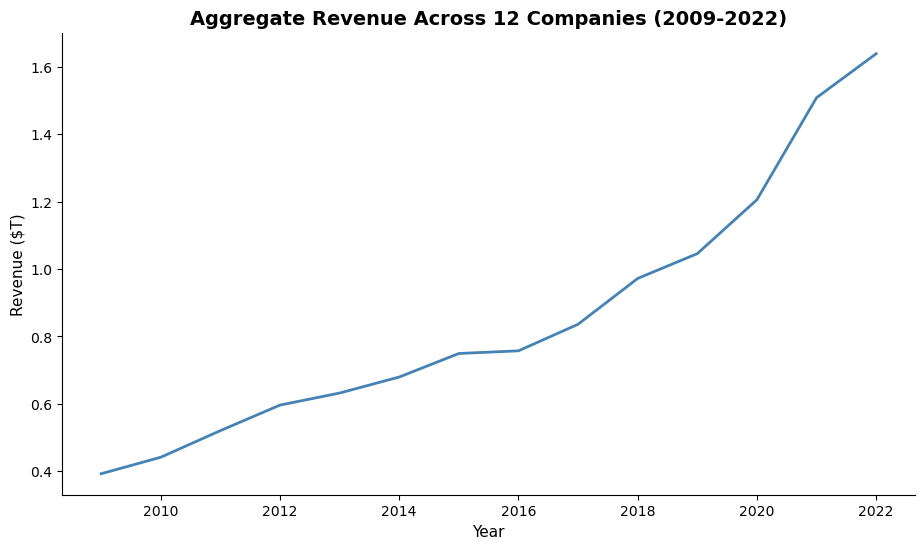

In [ ]:
# First Line Chart.
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(yearly["Year"], yearly["revenue_trillions"], color="steelblue", linewidth=2)
# ax.plot for Line Chart, ax.bar for Bar Chart

ax.set_title("Aggregate Revenue Across 12 Companies (2009-2022)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Revenue ($T)", fontsize=11)

# Cleaner axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

In [4]:
# Compute Aggregate Revenue by Year.
yearly = df.groupby("Year").agg(
    total_revenue=("Revenue", "sum"),
    total_net_income=("Net Income", "sum"),
).reset_index()

# Convert to trillions for readability
yearly["revenue_trillions"] = yearly["total_revenue"] / 1_000_000
yearly["ni_trillions"] = yearly["total_net_income"] / 1_000_000

yearly

,Year,total_revenue,total_net_income,revenue_trillions,ni_trillions
0,2009,392406.599,33642.8290,0.392407,0.033643
1,2010,441318.115,69186.4230,0.441318,0.069186
2,2011,520314.129,105264.2260,0.520314,0.105264
3,2012,596125.990,85923.8010,0.596126,0.085924
4,2013,631862.549,97490.9928,0.631863,0.097491
5,2014,679444.450,100202.0284,0.679444,0.100202
6,2015,749265.160,100709.9040,0.749265,0.100710
7,2016,757164.440,106880.6300,0.757164,0.106881
8,2017,836067.150,98653.2270,0.836067,0.098653
9,2018,971994.230,143613.0110,0.971994,0.143613


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SCRIPT_DIR = Path().resolve()
df = pd.read_csv(SCRIPT_DIR / "data" / "Financial Statements.csv")
df.columns = df.columns.str.strip()

sector_map = {
    "IT": "Technology", "LOGI": "Logistics", "FOOD": "Food & Beverage",
    "BANK": "Banking", "ELEC": "Electronics", "FinTech": "FinTech",
    "Finance": "Finance", "Manufacturing": "Manufacturing",
}
df["sector"] = df["Category"].map(sector_map)
df = df[(df["Year"] >= 2009) & (df["Year"] <= 2022)]